In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_processed
from src.models import portfolio_daily_returns
from src.evaluate import performance_metrics

tsla = load_processed("TSLA")
bnd = load_processed("BND")
spy = load_processed("SPY")

In [2]:
backtest_start = "2025-01-01"
backtest_end = "2026-06-30"

tsla_bt = tsla.loc[backtest_start:backtest_end]
bnd_bt = bnd.loc[backtest_start:backtest_end]
spy_bt = spy.loc[backtest_start:backtest_end]

print(f"Backtest period: {tsla_bt.index.min()} to {tsla_bt.index.max()} ({len(tsla_bt)} days)")

Backtest period: 2025-01-02 00:00:00 to 2026-06-29 00:00:00 (372 days)


In [3]:
returns_bt = pd.DataFrame({
    "TSLA": tsla_bt["Adj Close"].pct_change(),
    "BND": bnd_bt["Adj Close"].pct_change(),
    "SPY": spy_bt["Adj Close"].pct_change()
}).dropna()

returns_bt.head()

,TSLA,BND,SPY
Date,,,
2025-01-03,0.082156,-0.001251,0.012503
2025-01-06,0.001486,-0.000974,0.005761
2025-01-07,-0.040603,-0.003483,-0.011304
2025-01-08,0.001471,0.001118,0.001461
2025-01-10,-0.000506,-0.005167,-0.015268


In [4]:
strategy_weights = {"TSLA": 0.0, "BND": 0.0, "SPY": 1.0}
benchmark_weights = {"TSLA": 0.0, "BND": 0.40, "SPY": 0.60}

strategy_returns = portfolio_daily_returns(returns_bt, strategy_weights)
benchmark_returns = portfolio_daily_returns(returns_bt, benchmark_weights)

strategy_cumulative = (1 + strategy_returns).cumprod()
benchmark_cumulative = (1 + benchmark_returns).cumprod()

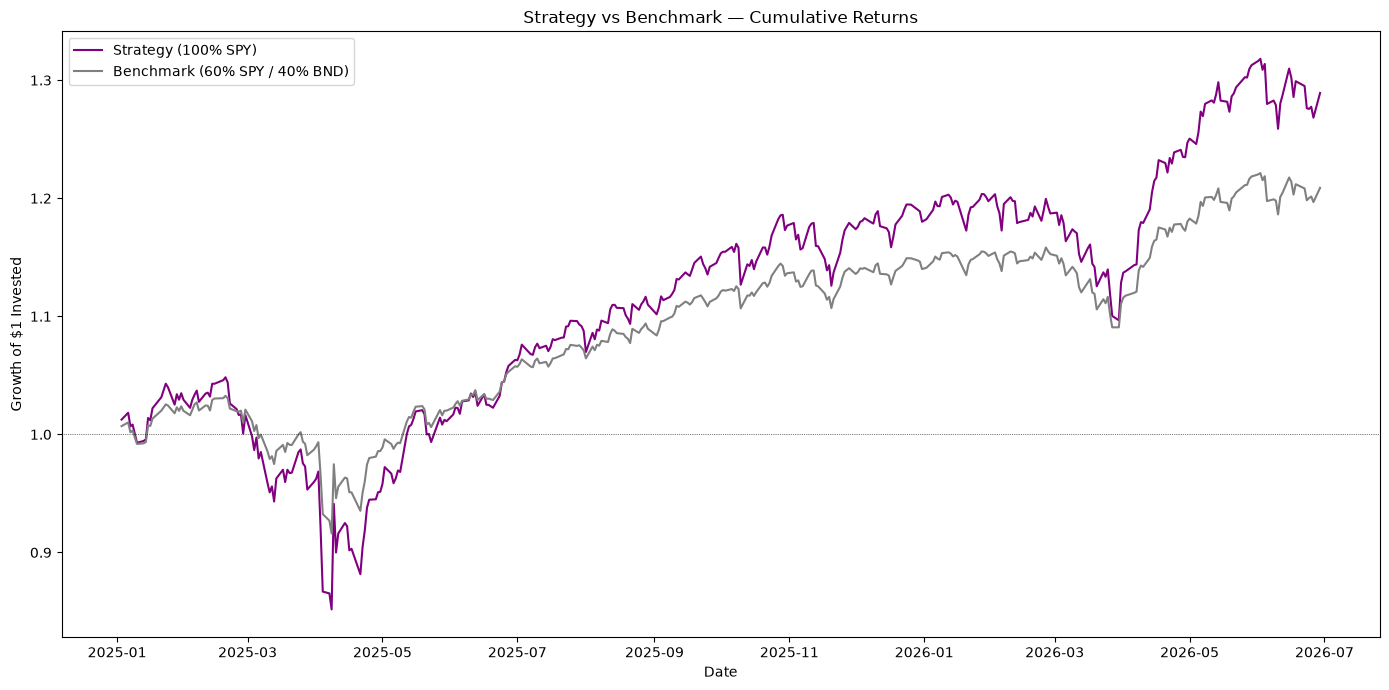

In [5]:
plt.figure(figsize=(14,7))
plt.plot(strategy_cumulative.index, strategy_cumulative, label="Strategy (100% SPY)", color="purple")
plt.plot(benchmark_cumulative.index, benchmark_cumulative, label="Benchmark (60% SPY / 40% BND)", color="gray")
plt.axhline(1.0, color="black", linewidth=0.5, linestyle=":")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Invested")
plt.title("Strategy vs Benchmark — Cumulative Returns")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
strategy_metrics = performance_metrics(strategy_returns, strategy_cumulative)
benchmark_metrics = performance_metrics(benchmark_returns, benchmark_cumulative)

comparison = pd.DataFrame({
    "Strategy (100% SPY)": strategy_metrics,
    "Benchmark (60/40)": benchmark_metrics
})

# Convert to object dtype so we can safely mix strings and numbers when formatting
comparison_display = comparison.astype(object).copy()
percent_rows = ["total_return", "annualized_return", "annualized_volatility", "max_drawdown"]
for row in percent_rows:
    comparison_display.loc[row] = comparison_display.loc[row].apply(lambda x: f"{x*100:.2f}%")
comparison_display.loc["sharpe_ratio"] = comparison_display.loc["sharpe_ratio"].apply(lambda x: f"{x:.3f}")
print(comparison_display)

                      Strategy (100% SPY) Benchmark (60/40)
total_return                       28.91%            20.88%
annualized_return                  18.83%            13.75%
annualized_volatility              17.94%            11.20%
sharpe_ratio                        0.827             0.870
max_drawdown                      -18.76%           -11.29%


## Backtest Conclusion

The model-driven strategy (100% SPY, per Task 4's Max Sharpe recommendation) 
outperformed the static 60/40 SPY/BND benchmark on total return (28.91% vs 20.88%) 
and annualized return (18.83% vs 13.75%) over the Jan 2025 - Jun 2026 backtest period.

However, this came with meaningfully higher risk: volatility of 17.94% vs 11.20%, 
and a deeper max drawdown of -18.76% vs -11.29% (visible clearly around April 2025). 
The benchmark actually achieved a slightly better risk-adjusted return (Sharpe 0.870 
vs 0.827), meaning the strategy's extra return didn't fully compensate for the extra 
risk taken.

**What this suggests about viability:** the strategy's outperformance here largely 
reflects that SPY simply had a strong run over this specific period, not necessarily 
that the model-driven allocation process added genuine skill — since, as discussed in 
Task 4, the "optimization" collapsed to a single-asset bet (100% SPY) as a direct 
consequence of a highly uncertain and likely overstated bearish TSLA forecast.

**Limitations:** this is a single backtest over one 18-month window with no 
rebalancing, no transaction costs, and a TSLA allocation forced to zero by a 
forecasting methodology we've already flagged as unreliable at long horizons. A more 
robust validation would test across multiple time periods, include realistic trading 
costs, and stress-test sensitivity to the forecast inputs before this strategy could 
be recommended with real confidence.